In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

df = pd.read_csv("/Users/purikunsrinor/Project/Myself/kaggle practice/credit-risk-model/data/processed/cs-training_cleaned.csv", index_col=0)

X = df.drop("SeriousDlqin2yrs", axis = 1)
y = df["SeriousDlqin2yrs"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [5]:
X_train_fe = X_train.copy()
X_val_fe = X_val.copy()

# Feature 1: Combine all debt late
X_train_fe['total_late_payment'] = (X_train_fe['NumberOfTime30-59DaysPastDueNotWorse'] + X_train_fe['NumberOfTimes90DaysLate'] + X_train_fe['NumberOfTime60-89DaysPastDueNotWorse'])
X_val_fe['total_late_payment'] = (X_val_fe['NumberOfTime30-59DaysPastDueNotWorse'] + X_val_fe['NumberOfTime60-89DaysPastDueNotWorse'] + X_val_fe['NumberOfTimes90DaysLate'])

# Feature 2: Debt per month
X_train_fe['monthly_debt'] = X_train_fe['DebtRatio'] * X_train_fe['MonthlyIncome']
X_val_fe['monthly_debt'] = X_val_fe['DebtRatio'] * X_val_fe['MonthlyIncome']

# Feature 3: income per debt
X_train_fe['income_to_debt'] = X_train_fe['MonthlyIncome'] / (X_train_fe['monthly_debt'] + 1)
X_val_fe['income_to_debt'] = X_val_fe['MonthlyIncome'] / (X_val_fe['monthly_debt'] + 1)

print(f"Features change from {X_train.shape[1]} to {X_train_fe.shape[1]}")


Features change from 11 to 14


In [6]:
best_params = {
    'subsample': 0.9,
    'scale_pos_weight': 10,
    'n_estimators': 300,
    'max_depth': 4,
    'learning_rate': 0.05,
    'colsample_bytree': 0.8
}

# old features
xgb_baseline = XGBClassifier(**best_params, 
                             random_state=42, 
                             eval_metric='auc', 
                             n_jobs=-1)

xgb_baseline.fit(X_train, y_train)
auc_baseline = roc_auc_score(y_val, xgb_baseline.predict_proba(X_val)[:, 1])

# new features
xgb_fe = XGBClassifier(**best_params, 
                             random_state=42, 
                             eval_metric='auc', 
                             n_jobs=-1)
xgb_fe.fit(X_train_fe, y_train)
auc_fe = roc_auc_score(y_val, xgb_fe.predict_proba(X_val_fe)[:, 1])

print(f"Without FE: {auc_baseline:.4f}")
print(f"With FE: {auc_fe:.4f}")




Without FE: 0.8693
With FE: 0.8700


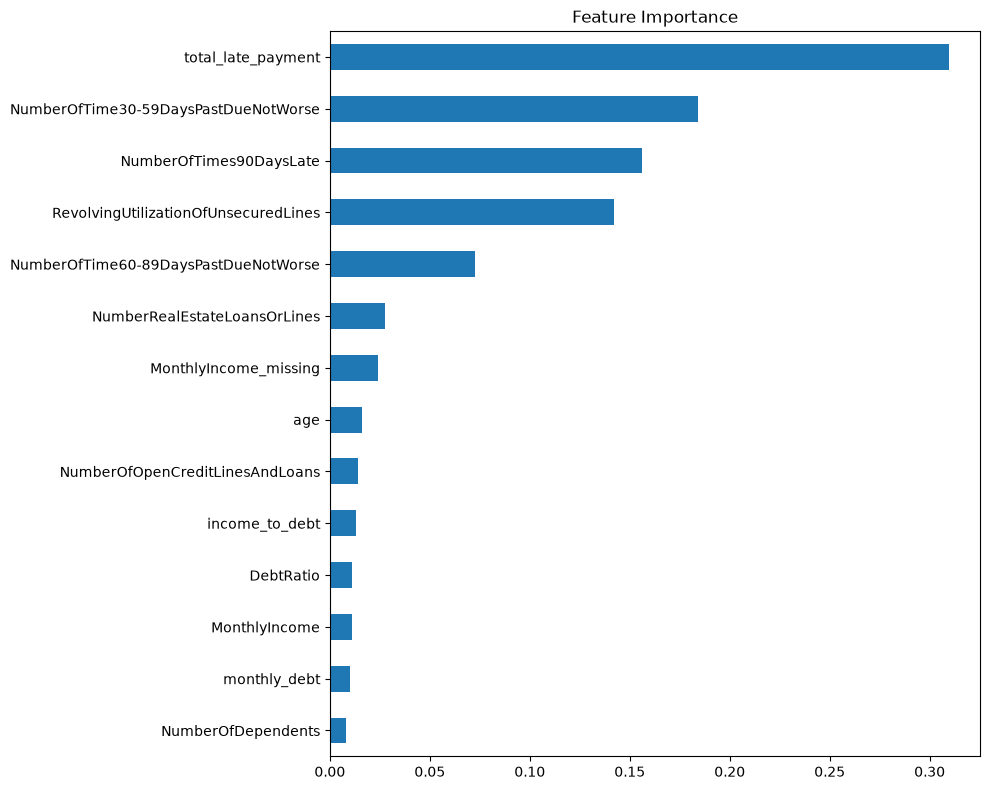

In [7]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(
    xgb_fe.feature_importances_,
    index=X_train_fe.columns
).sort_values(ascending=True)

feat_imp.plot(kind='barh', figsize=(10, 8))
plt.title('Feature Importance')
plt.tight_layout()
plt.show()